In [1]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision.datasets import ImageFolder

In [3]:
# Datasets & DataLoaders
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = ImageFolder(root="./PetImages", transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

trainset, testset = random_split(dataset, [train_size, test_size])

In [4]:
trainloader = DataLoader(trainset, batch_size=32, shuffle=True, num_workers=0)
testloader = DataLoader(testset, batch_size=32, num_workers=0)

### Build Our Model

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  
           

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
           
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(8*8*128, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  #flattening
        x = self.fc_layers(x)

        return x

In [6]:
model = CNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.0005, weight_decay=1e-4)

### Training Our Model

In [7]:
epochs = 10
best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    epoch_training_loss = 0.0   
    
    for images, labels in trainloader:
        
        optimizer.zero_grad()
        output = model.forward(images)
        loss = criterion(output, labels) 
        loss.backward()  
        optimizer.step()  

        epoch_training_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs} done")
    
    # Validation

    model.eval()
    epoch_val_loss = 0.0
    
    with torch.no_grad(): 
        for images, labels in testloader:
            output =  model.forward(images)
            loss = criterion(output, labels)
            epoch_val_loss += loss.item()

    train_losses.append(epoch_training_loss / len(trainloader))
    val_losses.append(epoch_val_loss / len(testloader))
        
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
    # else:
    #     break

        
print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")    

C:\Users\Aman\anaconda3\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1/10 done
Epoch 2/10 done
Epoch 3/10 done
Epoch 4/10 done
Epoch 5/10 done
Epoch 6/10 done
Epoch 7/10 done
Epoch 8/10 done
Epoch 9/10 done
Epoch 10/10 done
Epoch 10/10 | Train Loss: 0.2781 | Val Loss: 0.2804


### Evaluate our CNN


In [8]:
all_preds = []
all_labels = []

with torch.no_grad():
    model.eval()
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds))
print("Recall:", recall_score(all_labels, all_preds))
print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))

Accuracy: 0.8874
Precision: 0.9156369833830422
Recall: 0.854813046937152
Confusion Matrix:
 [[2288  198]
 [ 365 2149]]


In [9]:
torch.save(model.state_dict(), "cat_dog_model.pth")

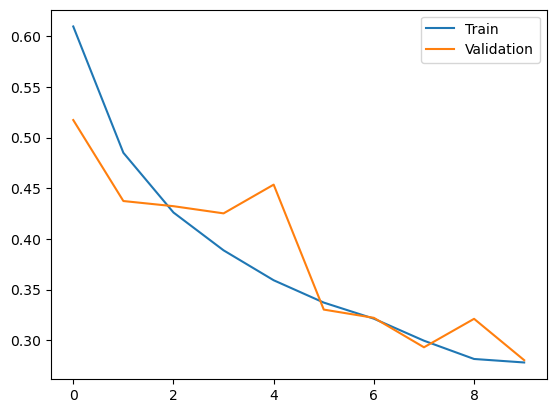

In [10]:
# Visualize

import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.show()